# FWI — Pearson Correlation Heatmap — MRI-ESM2-0 (Thailand)

**Part 2 — Analysis:** Reads precomputed means from cache and produces the Pearson-r correlation heatmap (FWI vs. climate drivers).

## 1  Dependencies

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
from pathlib import Path
from scipy.stats import pearsonr, linregress


## 2  Configuration

In [5]:
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")

SCENARIOS = [
    "historical", "ssp119", "ssp126", "ssp245",
    "ssp370", "ssp434", "ssp460", "ssp534", "ssp585",
]

SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0",
    "ssp434": "SSP4-3.4",
    "ssp460": "SSP4-6.0",
    "ssp534": "SSP5-3.4",
    "ssp585": "SSP5-8.5",
}


## 3  Pearson Correlation and Heatmap

## 8  Pearson correlation, slope & intercept (driver vs FWI)

Area-weighted annual mean per scenario, then Pearson r / OLS slope / intercept reported per scenario and for all scenarios combined.

In [8]:
from scipy.stats import pearsonr, linregress
import pandas as pd

def pearson_driver_vs_fwi(
    fwi_means:    dict,
    driver_means: dict,
    var_label:    str,
    scenarios:    list,
    labels:       dict,
    scale:        float = 1.0,
    offset:       float = 0.0,
) -> pd.DataFrame:
    """
    Pearson r, slope, intercept between one climate driver and FWI.

    Uses precomputed dicts from ``_compute_var_means_region`` — no raw data needed.

    Parameters
    ----------
    fwi_means    : {scen: DataArray}  — ensemble_means_th_all_scenarios
    driver_means : {scen: DataArray}  — e.g. tasmax_means_all_scenarios
    var_label    : display name for print header, e.g. "tasmax (°C)"
    scale        : unit multiplier applied to driver (pr: 86 400 → mm day⁻¹)
    offset       : unit offset applied after scale (tasmax: −273.15 → °C)
    """
    combined_drv, combined_fwi = [], []
    rows = []

    for scen in scenarios:
        fwi_da = fwi_means[scen]
        t      = fwi_da["year"]
        fwi_v  = fwi_da.values
        drv_v  = (driver_means[scen].sel(year=t, method="nearest") * scale + offset).values

        mask = ~np.isnan(drv_v) & ~np.isnan(fwi_v)
        drv_v, fwi_v = drv_v[mask], fwi_v[mask]
        if len(drv_v) < 2:
            continue

        r, _                 = pearsonr(drv_v, fwi_v)
        slope, intercept, *_ = linregress(drv_v, fwi_v)
        rows.append({"Scenario": labels[scen],
                     "r": round(r, 4),
                     "slope": round(slope, 4),
                     "intercept": round(intercept, 4)})
        combined_drv.extend(drv_v)
        combined_fwi.extend(fwi_v)

    if combined_drv:
        r, _                 = pearsonr(combined_drv, combined_fwi)
        slope, intercept, *_ = linregress(combined_drv, combined_fwi)
        rows.append({"Scenario": "ALL (combined)",
                     "r": round(r, 4),
                     "slope": round(slope, 4),
                     "intercept": round(intercept, 4)})

    df = pd.DataFrame(rows)
    print(f"\n── {var_label} vs FWI — Thailand ──")
    print(df.to_string(index=False))
    return df


In [9]:
# ── Pearson correlation: FWI vs 4 drivers ────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

_fwi  = _ld("fwi")
_tas  = _ld("tasmax")
_pr   = _ld("pr")
_wind = _ld("sfcWind")
_hurs = _ld("hurs")

df_tasmax = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_tas,
    var_label="tasmax (°C)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=1.0, offset=-273.15)

df_pr = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_pr,
    var_label="pr (mm day⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=86_400.0)

df_wind = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_wind,
    var_label="sfcWind (m s⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)

df_hurs = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_hurs,
    var_label="hurs (%)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)


── tasmax (°C) vs FWI — Thailand ──
      Scenario      r  slope  intercept
    Historical 0.7473 5.0197  -125.0467
      SSP1-1.9 0.7158 3.8510   -93.5241
      SSP1-2.6 0.5957 2.5277   -53.8442
      SSP2-4.5 0.8254 2.9598   -66.9425
      SSP3-7.0 0.9017 2.7246   -59.5877
      SSP4-3.4 0.7623 4.1264  -101.9277
      SSP4-6.0 0.7195 3.4233   -80.9143
      SSP5-3.4 0.7173 5.2805  -138.6542
      SSP5-8.5 0.8670 2.0527   -39.4609
ALL (combined) 0.8203 2.6249   -56.7139

── pr (mm day⁻¹) vs FWI — Thailand ──
      Scenario       r   slope  intercept
    Historical -0.7546 -4.1573    41.7894
      SSP1-1.9 -0.2612 -2.1995    33.7884
      SSP1-2.6 -0.0599 -0.4423    24.4966
      SSP2-4.5 -0.0701 -0.8631    27.5197
      SSP3-7.0 -0.4594 -6.5578    56.6718
      SSP4-3.4 -0.6158 -6.6799    57.5056
      SSP4-6.0 -0.2802 -2.5962    36.9364
      SSP5-3.4 -0.5502 -4.5824    48.5320
      SSP5-8.5  0.0553  0.7171    20.4992
ALL (combined) -0.4457 -4.4868    46.2017

── sfcWind (m s⁻¹) vs

In [10]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.ticker
import matplotlib.pyplot as plt


# ── Matplotlib-style heatmap helpers ──────────────────────────────────────────

def heatmap(data, row_labels, col_labels, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    if ax is None:
        ax = plt.gca()
    if cbar_kw is None:
        cbar_kw = {}

    im = ax.imshow(data, **kwargs)

    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    cbar.outline.set_linewidth(0.5)   # thin colorbar border

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, fontsize=14)
    ax.set_yticklabels(row_labels, fontsize=14)

    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right", rotation_mode="anchor")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(len(col_labels) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(row_labels) + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle="-", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"),
                     threshold=0.5, **textkw):
    if data is None:
        data = im.get_array()

    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val   = data[i, j]
            color = textcolors[1] if abs(val) > threshold else textcolors[0]
            text  = im.axes.text(j, i, valfmt(val, None), color=color, **kw)
            texts.append(text)
    return texts


# ── Main plot function ─────────────────────────────────────────────────────────

def plot_fwi_corr_heatmap(
    fwi_means:    dict,
    tasmax_means: dict,
    pr_means:     dict,
    wind_means:   dict,
    hurs_means: dict,
    scenarios:    list,
    labels:       dict,
    filename:     str = "fwi_correlation_MRI-ESM2-0.png",
) -> None:
    corr_data = []
    for scen in scenarios:
        fwi_da  = fwi_means[scen]
        t       = fwi_da["year"]
        fwi_v   = fwi_da.values
        tas_v   = (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values
        pr_v    = (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values
        wind_v  =  wind_means[scen].sel( year=t, method="nearest").values
        hurs_v = hurs_means[scen].sel(year=t, method="nearest").values

        df = pd.DataFrame({
            "FWI":        fwi_v,
            "Max Temp":   tas_v,
            "Precip":     pr_v,
            "Wind":       wind_v,
            "Humidity": hurs_v,
        }).corr()
        row      = df["FWI"].drop("FWI")
        row.name = labels.get(scen, scen)
        corr_data.append(row)

    final_corr_matrix = pd.concat(corr_data, axis=1).T
    data_arr  = final_corr_matrix.values
    row_lbls  = list(final_corr_matrix.index)
    col_lbls  = list(final_corr_matrix.columns)

    fig, ax = plt.subplots(figsize=(6, 6))

    def _fmt(x, pos):
        return f"{x:.2f}".replace("0.", ".").replace("-0.", "-.")

    im, _ = heatmap(
        data_arr, row_lbls, col_lbls, ax=ax,
        cmap="RdBu_r", vmin=-1, vmax=1,
        cbar_kw=dict(shrink=0.8, fraction=0.046, pad=0.04,
                     ticks=[-1, -0.5, 0, 0.5, 1]),
        cbarlabel="Pearson correlation (r)",
    )
    annotate_heatmap(im, data=data_arr,
                     valfmt=matplotlib.ticker.FuncFormatter(_fmt),
                     size=14, threshold=0.5,
                     textcolors=("black", "white"))

    ax.set_title("MRI-ESM2-0 : FWI vs Climate Drivers", pad=20, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

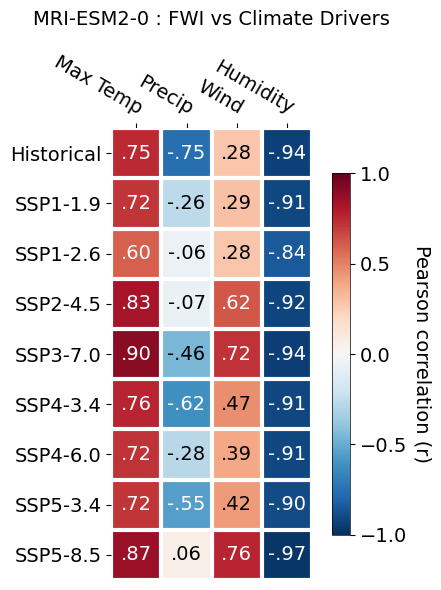

In [11]:
# ── Correlation heatmap: FWI vs 4 drivers ─────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

plot_fwi_corr_heatmap(
    fwi_means    = _ld("fwi"),
    tasmax_means = _ld("tasmax"),
    pr_means     = _ld("pr"),
    wind_means   = _ld("sfcWind"),
    hurs_means   = _ld("hurs"),
    scenarios    = SCENARIOS,
    labels       = SCENARIO_LABELS,
    filename     = "Pict/fwi_correlation_matrix_MRI-ESM2-0.png",
)